In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/retail-churn-project/data/retail-churn-project.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/drive/MyDrive/retail-churn-project/data/')

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/retail-churn-project/data/online_retail_II.csv')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
# ── STEP 2: Data Cleaning + Churn Labeling ──

# 1. Basic info
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

# 2. Drop rows with missing Customer ID (can't track churn without it)
df = df.dropna(subset=['Customer ID'])

# 3. Remove cancelled orders (Invoice starts with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# 4. Remove bad rows (negative or zero quantity/price)
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

# 5. Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 6. Create TotalAmount column
df['TotalAmount'] = df['Quantity'] * df['Price']

# 7. ── CHURN LABELING ──
# Define "churned" = customer who hasn't purchased in last 90 days
snapshot_date = df['InvoiceDate'].max()

customer_last_purchase = df.groupby('Customer ID')['InvoiceDate'].max().reset_index()
customer_last_purchase.columns = ['Customer ID', 'LastPurchaseDate']
customer_last_purchase['DaysSinceLastPurchase'] = (snapshot_date - customer_last_purchase['LastPurchaseDate']).dt.days
customer_last_purchase['Churned'] = (customer_last_purchase['DaysSinceLastPurchase'] > 90).astype(int)

print("\nChurn Distribution:")
print(customer_last_purchase['Churned'].value_counts())
print("\nSample:")
customer_last_purchase.head()

Shape: (1067371, 8)

Missing values:
 Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Churn Distribution:
Churned
1    2985
0    2893
Name: count, dtype: int64

Sample:


,Customer ID,LastPurchaseDate,DaysSinceLastPurchase,Churned
0,12346.0,2011-01-18 10:01:00,325,1
1,12347.0,2011-12-07 15:52:00,1,0
2,12348.0,2011-09-25 13:13:00,74,0
3,12349.0,2011-11-21 09:51:00,18,0
4,12350.0,2011-02-02 16:01:00,309,1


In [ ]:
# ── STEP 3: Build RFM Features ──

rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalAmount', 'sum')
).reset_index()

# Merge with churn labels
rfm = rfm.merge(customer_last_purchase[['Customer ID', 'Churned']], on='Customer ID')

print("RFM Table Shape:", rfm.shape)
print("\nSample:")
print(rfm.head(10))

print("\nRFM Stats:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

RFM Table Shape: (5878, 5)

Sample:
   Customer ID  Recency  Frequency  Monetary  Churned
0      12346.0      325         12  77556.46        1
1      12347.0        1          8   5633.32        0
2      12348.0       74          5   2019.40        0
3      12349.0       18          4   4428.69        0
4      12350.0      309          1    334.40        1
5      12351.0      374          1    300.93        1
6      12352.0       35         10   2849.84        0
7      12353.0      203          2    406.76        1
8      12354.0      231          1   1079.40        1
9      12355.0      213          2    947.61        1

RFM Stats:
           Recency    Frequency       Monetary
count  5878.000000  5878.000000    5878.000000
mean    200.331916     6.289384    3018.616737
std     209.338707    13.009406   14737.731040
min       0.000000     1.000000       2.950000
25%      25.000000     1.000000     348.762500
50%      95.000000     3.000000     898.915000
75%     379.000000     7.0000

✅ Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       589
           1       1.00      1.00      1.00       587

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176

🎯 ROC-AUC Score: 1.0


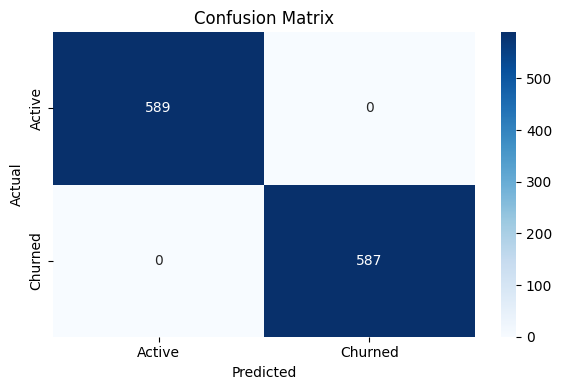

/tmp/ipykernel_2539/634430325.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


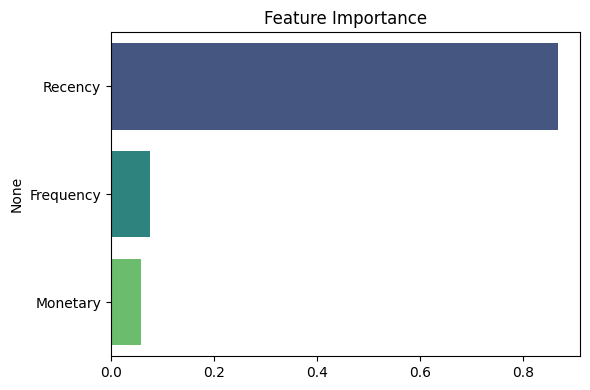

In [ ]:
# ── STEP 4: Train Random Forest Churn Prediction Model ──

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Features and target
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churned']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Results
print("✅ Classification Report:")
print(classification_report(y_test, y_pred))
print("🎯 ROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 4))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active','Churned'], yticklabels=['Active','Churned'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Feature Importance
plt.figure(figsize=(6,4))
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

✅ Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.64      0.67       589
           1       0.67      0.73      0.70       587

    accuracy                           0.69      1176
   macro avg       0.69      0.69      0.69      1176
weighted avg       0.69      0.69      0.69      1176

🎯 ROC-AUC Score: 0.7481


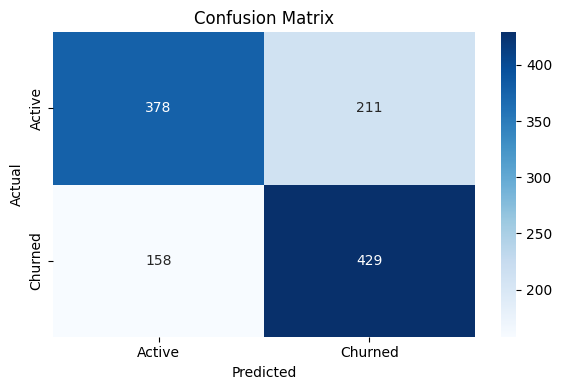

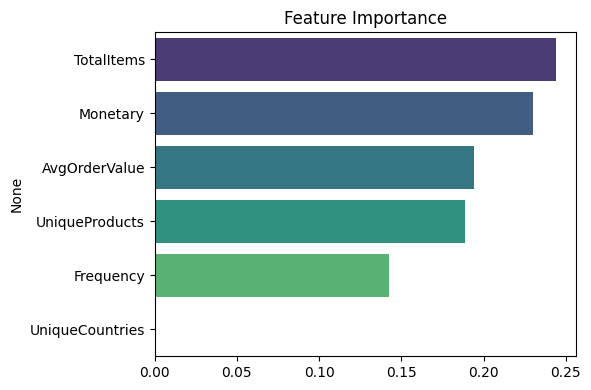

In [ ]:
# ── STEP 4 FIXED: Better Features ──

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Build richer features
customer_features = df.groupby('Customer ID').agg(
    Frequency       = ('Invoice', 'nunique'),
    Monetary        = ('TotalAmount', 'sum'),
    AvgOrderValue   = ('TotalAmount', 'mean'),
    TotalItems      = ('Quantity', 'sum'),
    UniqueProducts  = ('StockCode', 'nunique'),
    UniqueCountries = ('Country', 'nunique'),
).reset_index()

# Merge churn labels
customer_features = customer_features.merge(
    customer_last_purchase[['Customer ID', 'Churned']], on='Customer ID'
)

# Features and target (NO Recency this time)
X = customer_features[['Frequency','Monetary','AvgOrderValue',
                        'TotalItems','UniqueProducts','UniqueCountries']]
y = customer_features['Churned']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Results
print("✅ Classification Report:")
print(classification_report(y_test, y_pred))
print("🎯 ROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 4))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active','Churned'], yticklabels=['Active','Churned'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Feature Importance
plt.figure(figsize=(6,4))
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=feat_imp.values, y=feat_imp.index, hue=feat_imp.index, legend=False, palette='viridis')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
# ── STEP 5: Save Results ──

# Add churn probability to customer features
customer_features['ChurnProbability'] = model.predict_proba(
    customer_features[['Frequency','Monetary','AvgOrderValue',
                        'TotalItems','UniqueProducts','UniqueCountries']]
)[:, 1]

customer_features['RiskSegment'] = pd.cut(
    customer_features['ChurnProbability'],
    bins=[0, 0.4, 0.7, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print("Risk Segment Distribution:")
print(customer_features['RiskSegment'].value_counts())
print("\nSample High Risk Customers:")
print(customer_features[customer_features['RiskSegment'] == 'High Risk'].head())

# Save to CSV for SQL step next
customer_features.to_csv('/content/drive/MyDrive/retail-churn-project/data/customer_churn_features.csv', index=False)
print("\n✅ Saved to Google Drive!")

Risk Segment Distribution:
RiskSegment
Low Risk       2627
High Risk      2606
Medium Risk     582
Name: count, dtype: int64

Sample High Risk Customers:
   Customer ID  Frequency  Monetary  AvgOrderValue  TotalItems  \
0      12346.0         12  77556.46    2281.072353       74285   
4      12350.0          1    334.40      19.670588         197   
5      12351.0          1    300.93      14.330000         261   
7      12353.0          2    406.76      16.948333         212   
9      12355.0          2    947.61      27.074571         543   

   UniqueProducts  UniqueCountries  Churned  ChurnProbability RiskSegment  
0              27                1        1              0.75   High Risk  
4              17                1        1              0.95   High Risk  
5              21                1        1              0.94   High Risk  
7              23                1        1              0.90   High Risk  
9              35                1        1              0.95   High 